In [6]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
import tensorflow as tf
from tensorflow import keras

In [8]:
from tensorflow.keras.preprocessing.image import load_img

In [9]:
path = "../data/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name,target_size=(299,299))

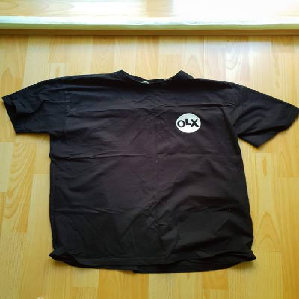

In [10]:
img

In [11]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x7C0C129DFA40>


In [12]:
#converting image to array
x = np.array(img)

In [13]:
# 3 channels with RGB
x.shape

(299, 299, 3)

## Pre-trained convolutional neural networks

- Imagenet Dataset: https://www.image-net.org/

- Pre-trained models: https://keras.io/api/applications/

In [14]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [15]:
model = Xception(weights="imagenet",input_shape=(299,299,3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
X = np.array([x])

In [17]:
X.shape

(1, 299, 299, 3)

In [18]:
X = preprocess_input(X)

In [19]:
X[0]

array([[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.41960788,  0.35686278, -0.20784312],
        ...,
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.99215686,  0.9372549 ]],

       [[ 0.47450984,  0.4039216 , -0.12156862],
        [ 0.4666667 ,  0.39607847, -0.12941176],
        [ 0.45882356,  0.38823533, -0.15294117],
        ...,
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.92941177]],

       [[ 0.56078434,  0.48235297, -0.00392157],
        [ 0.5686275 ,  0.4901961 ,  0.00392163],
        [ 0.5686275 ,  0.49803925, -0.01176471],
        ...,
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863]],

       ...,

       [[ 0.2941177 ,  0.18431377, -0.40392154],
        [ 0

In [20]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [21]:
pred.shape

(1, 1000)

In [22]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

## Transfer Learning

- Keep the convolutional layers of imagenet because its more generic

- train on the dataset we have this creates new denselayers

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [24]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds= train_gen.flow_from_directory("../data/train",target_size=(150,150),batch_size=32)

Found 3068 images belonging to 10 classes.


In [25]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [26]:
X,y = next(train_ds)

In [27]:
X.shape

(32, 150, 150, 3)

In [28]:
y[:5]

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [29]:
# for validation

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds= val_gen.flow_from_directory("../data/validation",target_size=  (150,150),batch_size=32,shuffle=False)

Found 341 images belonging to 10 classes.


In [30]:
# training a base model

base_model = Xception(weights='imagenet',include_top=False,input_shape=(150,150,3))

base_model.trainable = False

inputs = keras.Input(shape=(150,150,3))

base = base_model(inputs,training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs,outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [31]:
# to train model, we need optimiser, we need to change the weights which lead to better solution

learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])

In [32]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 50s 357ms/step - accuracy: 0.5565 - loss: 1.8584 - val_accuracy: 0.7243 - val_loss: 0.9387
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8010 - loss: 0.6041 - val_accuracy: 0.7771 - val_loss: 0.8612
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.8829 - loss: 0.3427 - val_accuracy: 0.8182 - val_loss: 0.7863
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9212 - loss: 0.2185 - val_accuracy: 0.8094 - val_loss: 0.8513
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9508 - loss: 0.1360 - val_accuracy: 0.8035 - val_loss: 0.8473
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9771 - loss: 0.0762 - val_accuracy: 0.8035 - val_loss: 0.7938
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9764 - loss: 0.0887 - val_accuracy: 0.8182 - val_loss: 0.8862
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9803 - loss: 0.0610 - val_accuracy: 0.8211 - val_loss: 

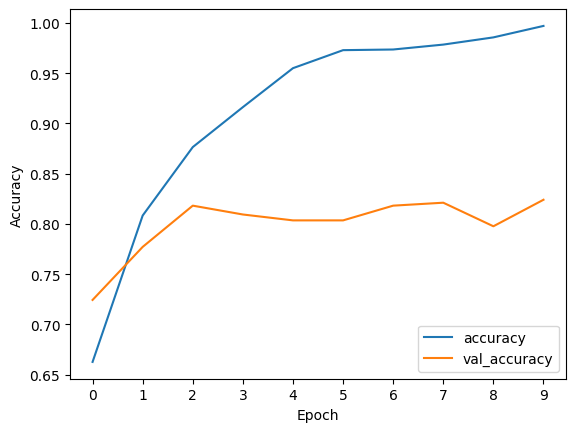

In [33]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(10))
plt.legend(loc='lower right')
plt.show()

# Adjusting the learning rate

In [34]:
def make_model(learning_rate = 0.01):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    ######################################################

    base_model.trainable = False
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [35]:
scores = {}
for lr in [0.0001,0.001,0.01,0.1]:
    print(f"learning rate : {lr}")

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[lr]=history.history

    print()
    print()

learning rate : 0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 187ms/step - accuracy: 0.1944 - loss: 2.2241 - val_accuracy: 0.4780 - val_loss: 1.6457
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.5131 - loss: 1.5047 - val_accuracy: 0.6246 - val_loss: 1.2802
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.6213 - loss: 1.2071 - val_accuracy: 0.6774 - val_loss: 1.0951
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.6779 - loss: 1.0285 - val_accuracy: 0.7038 - val_loss: 0.9797
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6989 - loss: 0.9308 - val_accuracy: 0.7273 - val_loss: 0.8997
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.7234 - loss: 0.8828 - val_accuracy: 0.7419 - val_loss: 0.8457
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7395 - loss: 0.7955 - val_accuracy: 0.7595 - val_loss: 0.8037
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7582 - loss: 0.7735

In [36]:
lr_scores = scores

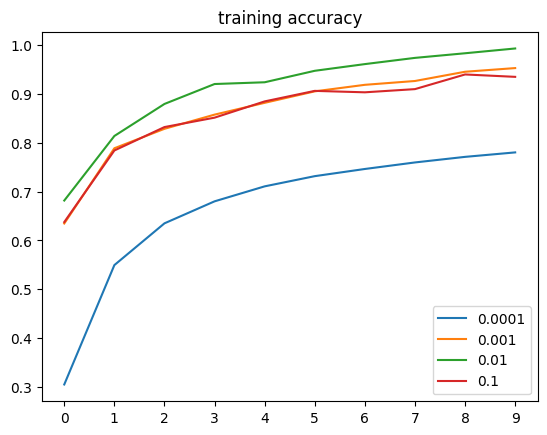

In [37]:

for lr, hist in lr_scores.items():
    plt.plot(hist['accuracy'],label=lr)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy')
plt.legend()

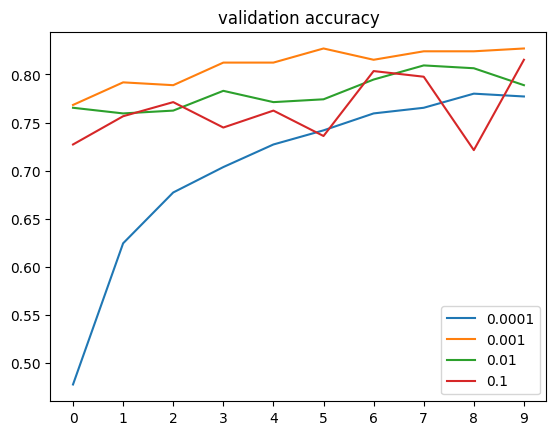

In [38]:
for lr, hist in lr_scores.items():
    #plt.plot(hist['accuracy'],label=lr)
    plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('validation accuracy')
plt.legend()

In [39]:
learning_rate=0.001

## Checkpointing

- Saving the best model only
- Traiing a model with callbacks

In [40]:
model.save_weights('model_v1.weights.h5')

In [41]:
epoch = 12
val_accuracy=0.824
f"xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5"

'xception_v1_12_0.824.h5'

In [42]:
checkpoint = keras.callbacks.ModelCheckpoint('xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only=True,
                                             monitor='val_accuracy',
                                             mode='max'
                                            )

In [43]:
learning_rate = 0.01

model = make_model(learning_rate=learning_rate)

history = model.fit(train_ds,epochs=10,
                    validation_data=val_ds,
                    callbacks=[checkpoint])



Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5903 - loss: 1.6813

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.5912 - loss: 1.6765 - val_accuracy: 0.7595 - val_loss: 0.7618
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8305 - loss: 0.4962

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8304 - loss: 0.4965 - val_accuracy: 0.7947 - val_loss: 0.7508
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8749 - loss: 0.3295 - val_accuracy: 0.7889 - val_loss: 0.8395
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9107 - loss: 0.2238 - val_accuracy: 0.7654 - val_loss: 0.9656
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9440 - loss: 0.1545

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9439 - loss: 0.1547 - val_accuracy: 0.7977 - val_loss: 0.9285
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9602 - loss: 0.1190 - val_accuracy: 0.7859 - val_loss: 0.9677
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9842 - loss: 0.0637 - val_accuracy: 0.7859 - val_loss: 1.0015
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9838 - loss: 0.0614

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9838 - loss: 0.0614 - val_accuracy: 0.8006 - val_loss: 0.8819
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9828 - loss: 0.0660

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9828 - loss: 0.0659 - val_accuracy: 0.8328 - val_loss: 0.8305
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9767 - loss: 0.0636 - val_accuracy: 0.7889 - val_loss: 1.0374


## Adding more layers
- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [44]:
def make_model(learning_rate = 0.01,size_inner=100):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    base_model.trainable = False
    ######################################################
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner,activation='relu')(vectors)
    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [47]:
learning_rate = 0.01

scores = {}

for size in [10,100,1000]:
    print(f"for size : {size}")

    model = make_model(learning_rate=learning_rate,size_inner=size)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[size]=history.history

    print()
    print()

for size : 10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 187ms/step - accuracy: 0.3939 - loss: 1.8588 - val_accuracy: 0.5455 - val_loss: 1.2491
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6172 - loss: 1.1108 - val_accuracy: 0.6686 - val_loss: 1.0047
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6894 - loss: 0.8878 - val_accuracy: 0.6921 - val_loss: 0.9285
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7434 - loss: 0.7344 - val_accuracy: 0.6804 - val_loss: 0.9555
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.7673 - loss: 0.6549 - val_accuracy: 0.6686 - val_loss: 0.9082
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7864 - loss: 0.5937 - val_accuracy: 0.7302 - val_loss: 0.8756
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8056 - loss: 0.5390 - val_accuracy: 0.7331 - val_loss: 0.8696
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8550 - loss: 0.4268 - val_accu

In [48]:
scores

{10: {'accuracy': [0.4735984206199646,
   0.6411342620849609,
   0.6975228190422058,
   0.7447848916053772,
   0.7620599865913391,
   0.8024771809577942,
   0.8070403933525085,
   0.8536505699157715,
   0.8719035387039185,
   0.8852672576904297],
  'loss': [1.5579277276992798,
   1.0627961158752441,
   0.877191960811615,
   0.7384247779846191,
   0.6698729991912842,
   0.5687273144721985,
   0.538586437702179,
   0.43458977341651917,
   0.3987950086593628,
   0.352355033159256],
  'val_accuracy': [0.5454545617103577,
   0.6686217188835144,
   0.6920821070671082,
   0.6803519129753113,
   0.6686217188835144,
   0.7302052974700928,
   0.733137845993042,
   0.7507331371307373,
   0.7653958797454834,
   0.7272727489471436],
  'val_loss': [1.2490659952163696,
   1.0046803951263428,
   0.9284887909889221,
   0.9554647207260132,
   0.9082452654838562,
   0.8755621910095215,
   0.8696040511131287,
   1.0371196269989014,
   0.9540653228759766,
   1.0514527559280396]},
 100: {'accuracy': [0.6395

In [49]:
inner_layer_size_scores = scores

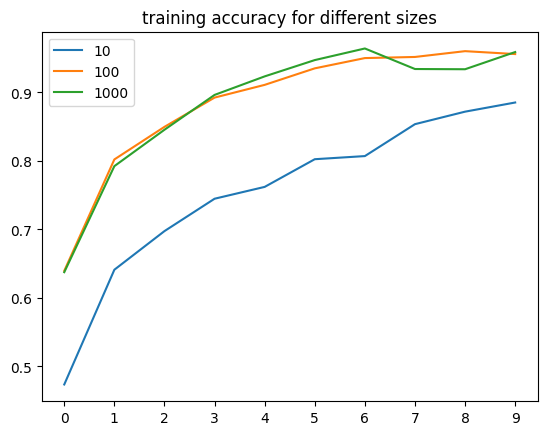

In [50]:

for size, hist in inner_layer_size_scores.items():
    plt.plot(hist['accuracy'],label=size)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy for different sizes')
plt.legend()

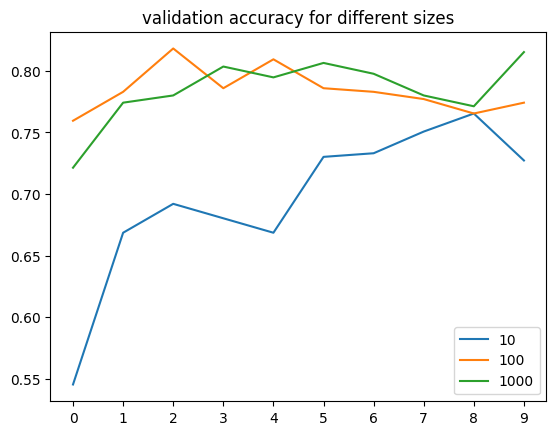

In [51]:

for size, hist in inner_layer_size_scores.items():
    #plt.plot(hist['accuracy'],label=size)
    plt.plot(hist['val_accuracy'],label=size)

plt.xticks(np.arange(10))
plt.title('validation accuracy for different sizes')
plt.legend()

## Regularizing by dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [52]:
def make_model(learning_rate = 0.01,size_inner=100,droprate=0.5):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    base_model.trainable = False
    ######################################################
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner,activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [53]:
learning_rate = 0.01
size = 100

scores = {}

for droprate in [0.0,0.2,0.5,0.8]:
    print(f"for droprate : {droprate}")

    model = make_model(learning_rate=learning_rate,size_inner=size,droprate=droprate)
    history = model.fit(train_ds,epochs=30,validation_data=val_ds)
    scores[droprate]=history.history

    print()
    print()

for droprate : 0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 191ms/step - accuracy: 0.5647 - loss: 1.6915 - val_accuracy: 0.7302 - val_loss: 0.8050
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7986 - loss: 0.5634 - val_accuracy: 0.7742 - val_loss: 0.7231
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8492 - loss: 0.4255 - val_accuracy: 0.7801 - val_loss: 0.6810
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8920 - loss: 0.3173 - val_accuracy: 0.7654 - val_loss: 0.7464
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9159 - loss: 0.2531 - val_accuracy: 0.7478 - val_loss: 0.8733
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9146 - loss: 0.2337 - val_accuracy: 0.7947 - val_loss: 0.8133
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9566 - loss: 0.1246 - val_accuracy: 0.7889 - val_loss: 0.9118
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9792 - loss: 0.0766 - val

In [54]:
droprate_scores= scores

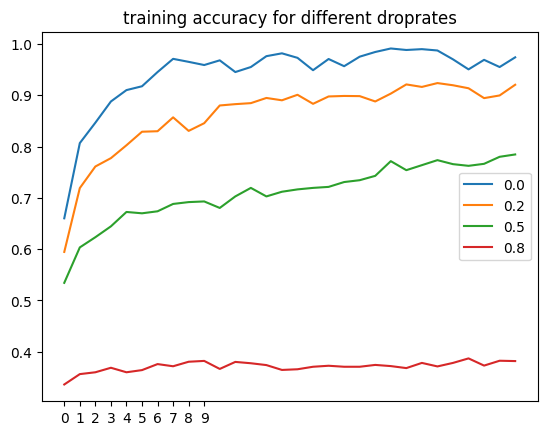

In [57]:

for droprate, hist in droprate_scores.items():
    plt.plot(hist['accuracy'],label=droprate)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy for different droprates')
plt.legend()

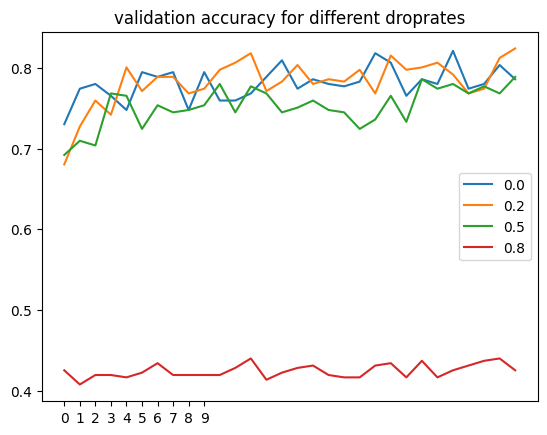

In [61]:

for droprate, hist in droprate_scores.items():
    #plt.plot(hist['accuracy'],label=size)
    plt.plot(hist['val_accuracy'],label=droprate)

plt.xticks(np.arange(10))
plt.title('validation accuracy for different droprates')
plt.legend()

In [62]:
droprate=0.2